epsilon=18.0 delta=7.8 chi=-0.1 kappa=2.875
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.62e+01       4.75e-03         10001          19963     
       2          3.14e-04       1.45e-03         29964            0       
       3          4.65e-04       1.81e-05         29964            0       
Solved in 3 iterations, number of nodes 29964. 
Maximum relative residual: 4.65e-04 
Maximum boundary residual: 1.81e-05


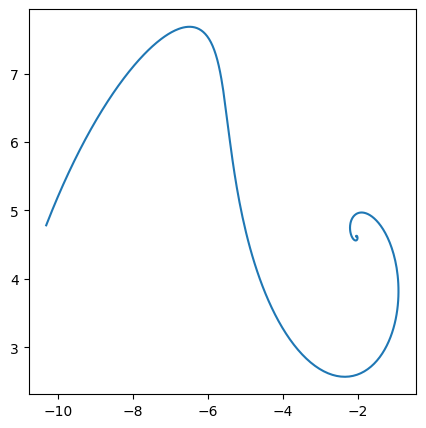

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  2.667e-04 ...  8.000e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f78ab687ab0>
             p: None
             y: [[-2.036e+00 -2.036e+00 ... -1.032e+01 -1.032e+01]
                 [ 4.620e+00  4.620e+00 ...  4.783e+00  4.783e+00]
                 [-1.025e-04 -1.023e-04 ... -1.119e-02 -1.118e-02]
                 [ 1.347e-04  1.350e-04 ...  1.175e-03  1.174e-03]]
            yp: [[ 4.211e-04  4.229e-04 ... -3.813e-02 -3.812e-02]
                 [ 9.110e-04  9.108e-04 ... -5.407e-02 -5.405e-02]
                 [ 6.252e-04  6.271e-04 ...  1.212e-02  1.212e-02]
                 [ 9.641e-04  9.644e-04 ... -1.581e-03 -1.581e-03]]
 rms_residuals: [ 4.388e-12  3.982e-12 ...  1.390e-08  1.390e-08]
         niter: 3
epsilon=18.0 delta=7.8 chi=-0.1 kappa=2.8625000000000003
   Iteration    Max residual  Max BC residual  Tot

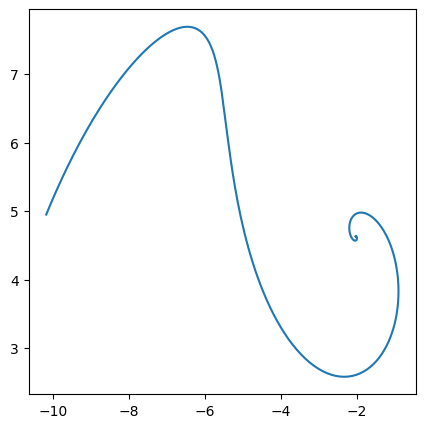

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  8.000e-04 ...  7.999e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f787aeca8e0>
             p: None
             y: [[-2.031e+00 -2.031e+00 ... -1.019e+01 -1.019e+01]
                 [ 4.628e+00  4.628e+00 ...  4.950e+00  4.950e+00]
                 [-1.024e-04 -1.019e-04 ... -9.257e-03 -9.248e-03]
                 [ 1.425e-04  1.433e-04 ...  1.066e-03  1.065e-03]]
            yp: [[ 4.545e-04  4.602e-04 ... -3.181e-02 -3.179e-02]
                 [ 9.452e-04  9.447e-04 ... -4.340e-02 -4.336e-02]
                 [ 6.740e-04  6.798e-04 ...  1.059e-02  1.058e-02]
                 [ 9.906e-04  9.913e-04 ... -1.419e-03 -1.419e-03]]
 rms_residuals: [ 3.760e-12  3.357e-12 ...  3.655e-06  3.655e-06]
         niter: 1


In [7]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List

from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.incoming_quantum_vector import extend_to_keldysh_state
from metastable.generate_guess import generate_linear_guess, generate_guess_from_sol
from metastable.generate_boundary_conditions import generate_boundary_condition_func


@dataclass
class IndexPair:
    epsilon_idx: int
    kappa_idx: int


map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/map.npz"
output_map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/scratch.npz"
fixed_point_map = FixedPointMap.load(map_path)

def extract_params(fixed_point_map: FixedPointMap, index_pair: IndexPair) -> Params:
    return Params(
        epsilon=fixed_point_map.epsilon_linspace[index_pair.epsilon_idx],
        kappa=fixed_point_map.kappa_linspace[index_pair.kappa_idx],
        delta=fixed_point_map.delta,
        chi=fixed_point_map.chi,
    )

def prepare_saddle_and_focus_points(fixed_point_map: FixedPointMap, index_pair: IndexPair) -> Tuple[np.ndarray, np.ndarray]:
    classical_saddle_point = fixed_point_map.fixed_points[index_pair.epsilon_idx, index_pair.kappa_idx, 0]
    classical_focus_point = fixed_point_map.fixed_points[index_pair.epsilon_idx, index_pair.kappa_idx, 2]
    
    keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
    keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
    
    return keldysh_saddle_point, keldysh_focus_point

def solve_bvp(eom: EOM, boundary_condition_func, t_guess: np.ndarray, y_guess: np.ndarray) -> scipy.integrate.OdeSolution:
    wrapper = lambda x, y: eom.y_dot_func(y)
    return scipy.integrate.solve_bvp(
        wrapper, boundary_condition_func, t_guess, y_guess, tol=1e-3, max_nodes=1000000, verbose=2
    )

def plot_solution(res: scipy.integrate.OdeSolution, t_guess: np.ndarray) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    t_plot = np.linspace(0, t_guess[-1], 1001)
    y0_plot = res.sol(t_plot)[0]
    y1_plot = res.sol(t_plot)[1]
    axes.plot(y0_plot, y1_plot)
    plt.show()

def process_index(fixed_point_map: FixedPointMap, index_pair: IndexPair, t_guess: np.ndarray, y_guess: np.ndarray) -> scipy.integrate.OdeSolution:
    params = extract_params(fixed_point_map, index_pair)
    print(params)
    
    eom = EOM(params=params)
    
    keldysh_saddle_point, keldysh_focus_point = prepare_saddle_and_focus_points(fixed_point_map, index_pair)
    
    boundary_condition_func = generate_boundary_condition_func(keldysh_saddle_point, keldysh_focus_point, params)
    
    path_result = solve_bvp(eom, boundary_condition_func, t_guess, y_guess)
    
    plot_solution(path_result, t_guess)
    
    print(path_result)
    
    return path_result

def generate_linear_guess_from_map(fixed_point_map: FixedPointMap, index_pair: IndexPair) -> Tuple[np.ndarray, np.ndarray]:
    classical_saddle_point = fixed_point_map.fixed_points[index_pair.epsilon_idx, index_pair.kappa_idx, 0]
    classical_focus_point = fixed_point_map.fixed_points[index_pair.epsilon_idx, index_pair.kappa_idx, 2]
    keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
    keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
    t_guess, y_guess = generate_linear_guess(keldysh_focus_point, keldysh_saddle_point, 8.0)
    
    return t_guess, y_guess

def map_switching_paths(fixed_point_map: FixedPointMap, index_list: List[IndexPair], output_map_path: str) -> List[scipy.integrate.OdeSolution]:
    
    t_guess, y_guess = generate_linear_guess_from_map(fixed_point_map, index_list[0])
    
    results = []
    
    for index_pair in index_list:                
        res = process_index(fixed_point_map, index_pair, t_guess, y_guess)
        fixed_point_map.path_results[index_pair.epsilon_idx, index_pair.kappa_idx] = res
        fixed_point_map.save_state(output_map_path)
        
        t_guess, y_guess = generate_guess_from_sol(bvp_result=res, t_end=8.0)
        
        results.append(res)
        
    return results

# Example list of IndexPair for epsilon and kappa indexes
epsilon_idx = 360
seed_kappa_idx = 230
index_list = [IndexPair(epsilon_idx, seed_kappa_idx), IndexPair(epsilon_idx, seed_kappa_idx-1)]

# Call the function with the list of IndexPair
results = map_switching_paths(fixed_point_map, index_list, output_map_path)